In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy 
import sys
sys.path.append("../src")

from Autograd import Tensor
from Activation import ReLU
from Loss import cross_entropy_loss
from Training import training
from Model import Sequential,Linear
from Optimiser import SGD,Momentum,RMSProp,Adagrad,Adadelta,Adam
from Testing import non_hot_one_accuracy

In previous models, I used full-batch or mini-batch stochastic gradient descent. Whilst these will work well for convex loss functions (due to the local minimum also being the global minimum), for non convex functions, we may get 'stuck' at local minima. 

Momentum takes into account the previous gradients; for example, if there is a sign change in the gradient due to a local minima, the 'velocity' could still be positive hence we can move past the local minimum.

Adagrad aims to adjust the update rule for different components depending on the history of the updates. If a certain parameter has had many large updates, it implies it is sensitive to change so the updates should be adjusted for that parameter. It does this by accumulation of the squared gradients to get a measure of the parameters sensitivity to change. 

RMSProp takes the same idea as Adagrad and improves on it. In particular, Adagrad was developed in the context of convex optimisation; the learning rate could decay very aggressively in non convex contexts which could result in getting stuck at local minima. RMSProp doesn't allow the state vector to grow uncontrollably large, hence the updates don't become too small too quickly.

Adadelta is another variation of Adagrad, which aims to adapt the learning rate of each parameter through each iteration.

Adam is a combination of the above techniques in one optimisation algorithm.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

mnist=fetch_openml("Fashion-MNIST",version=1,as_frame=False)

coords=mnist.data/255
classes=mnist.target.astype(int)

print(coords.shape)
print(classes.shape)

coords_train,coords_test,class_train,class_test=train_test_split(coords,classes,test_size=0.5,random_state=2)
coords_train,coords_test,class_train,class_test=Tensor(coords_train),Tensor(coords_test),Tensor(class_train),Tensor(class_test)

no_classes=10
no_samples=coords.shape[0]
no_features=coords.shape[1]

(70000, 784)
(70000,)


The Fashion MNIST data set is a classification problem where depending on the 28 by 28 matrix (representing the image of a piece of clothes), we need to deduce which type it is, there are 10 types.

Using deepcopies of the initial model ensure there is not variation in the initialisation between the use of different optimisers.

In [3]:
loss_fn=cross_entropy_loss
epochs=20
batch_size=64

initial=Sequential([Linear(no_features,256),ReLU(),Linear(256,128),ReLU(),Linear(128,no_classes)])

SGD_model=copy.deepcopy(initial)
optimiser=SGD(SGD_model.parameters(),lr=0.001)
SGDloss=training(coords_train,SGD_model,class_train,loss_fn,epochs,optimiser,batch_size)

Momentum_model=copy.deepcopy(initial)
optimiser=Momentum(Momentum_model.parameters(),lr=0.001,beta=0.9)
Momentumloss=training(coords_train,Momentum_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adagrad_model=copy.deepcopy(initial)
optimiser=Adagrad(Adagrad_model.parameters(),lr=0.001,eta=0.9)
Adagradloss=training(coords_train,Adagrad_model,class_train,loss_fn,epochs,optimiser,batch_size)

RMSProp_model=copy.deepcopy(initial)
optimiser=RMSProp(RMSProp_model.parameters(),lr=0.001,gamma=0.9)
RMSProploss=training(coords_train,RMSProp_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adadelta_model=copy.deepcopy(initial)
optimiser=Adadelta(Adadelta_model.parameters(),rho=0.95)
Adadeltaloss=training(coords_train,Adadelta_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adam_model=copy.deepcopy(initial)
optimiser=Adam(Adam_model.parameters(),lr=0.001,beta1=0.9,beta2=0.999)
Adamloss=training(coords_train,Adam_model,class_train,loss_fn,epochs,optimiser,batch_size)

Epoch  1 loss:  1.9308790620911014
Epoch  2 loss:  1.4135065680328085
Epoch  3 loss:  1.1342876781851197
Epoch  4 loss:  0.9806571166167275
Epoch  5 loss:  0.8878134057346404
Epoch  6 loss:  0.8257313166084584
Epoch  7 loss:  0.780652587714062
Epoch  8 loss:  0.7455751944654498
Epoch  9 loss:  0.7168783947784252
Epoch  10 loss:  0.6929933131301934
Epoch  11 loss:  0.6724641448745639
Epoch  12 loss:  0.6545004307797039
Epoch  13 loss:  0.6387645991244477
Epoch  14 loss:  0.6244651052846799
Epoch  15 loss:  0.6117479806482599
Epoch  16 loss:  0.6002930400249362
Epoch  17 loss:  0.5899280674901548
Epoch  18 loss:  0.5804924726196105
Epoch  19 loss:  0.5718005377956138
Epoch  20 loss:  0.5638865162619363
Epoch  1 loss:  1.0531658173270668
Epoch  2 loss:  0.6276283656070818
Epoch  3 loss:  0.5467637800850139
Epoch  4 loss:  0.5059143326845567
Epoch  5 loss:  0.48008043422815205
Epoch  6 loss:  0.45931234220643047
Epoch  7 loss:  0.4435944071308782
Epoch  8 loss:  0.43360480544681884
Epoch  

As its a classification problem, i use cross entropy loss as the loss function. I use copies of the initial model as there won't be any difference in the initialisation of the parameters for each model.

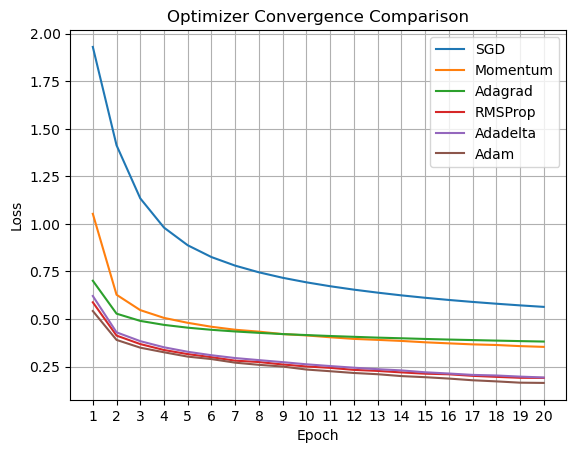

In [4]:
plt.plot(np.arange(1,epochs+1),SGDloss,label="SGD")
plt.plot(np.arange(1,epochs+1),Momentumloss,label="Momentum")
plt.plot(np.arange(1,epochs+1),Adagradloss,label="Adagrad")
plt.plot(np.arange(1,epochs+1),RMSProploss,label="RMSProp")
plt.plot(np.arange(1,epochs+1),Adadeltaloss,label="Adadelta")
plt.plot(np.arange(1,epochs+1),Adamloss,label="Adam")

plt.xticks(np.arange(1, epochs + 1, 1))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Convergence Comparison")

plt.legend()
plt.grid(True)
plt.savefig("Optimiser_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

We can see that the adaptive optimisers all learn much quicker with much lower losses after just one epoch. Adam, Adadelta and RMSProp all decrease in loss much more quickly.

In [5]:
print("SGD final training loss and accuracy: ",SGDloss[-1],non_hot_one_accuracy(SGD_model.forward_prop(coords_train),class_train))
print("Momentum final training loss and accuracy: ",Momentumloss[-1],non_hot_one_accuracy(Momentum_model.forward_prop(coords_train),class_train))
print("Adagrad final training loss and accuracy: ",Adagradloss[-1],non_hot_one_accuracy(Adagrad_model.forward_prop(coords_train),class_train))
print("RMSProp final training loss and accuracy: ",RMSProploss[-1],non_hot_one_accuracy(RMSProp_model.forward_prop(coords_train),class_train))
print("Adadelta final training loss and accuracy: ",Adadeltaloss[-1],non_hot_one_accuracy(Adadelta_model.forward_prop(coords_train),class_train))
print("Adam final training loss and accuracy: ",Adamloss[-1],non_hot_one_accuracy(Adam_model.forward_prop(coords_train),class_train))

SGD final training loss and accuracy:  0.5638865162619363 0.8166571428571429
Momentum final training loss and accuracy:  0.3535431213802988 0.8784285714285714
Adagrad final training loss and accuracy:  0.38156946562420035 0.8706
RMSProp final training loss and accuracy:  0.1904425351257376 0.9389714285714286
Adadelta final training loss and accuracy:  0.1926341865063274 0.9325714285714286
Adam final training loss and accuracy:  0.1639983260973845 0.9478285714285715


In [6]:
SGDtest=SGD_model.forward_prop(coords_test)
Momentumtest=Momentum_model.forward_prop(coords_test)
Adagradtest=Adagrad_model.forward_prop(coords_test)
RMSProptest=RMSProp_model.forward_prop(coords_test)
Adadeltatest=Adadelta_model.forward_prop(coords_test)
Adamtest=Adam_model.forward_prop(coords_test)

SGDLoss=cross_entropy_loss(SGDtest,class_test)
MomentumLoss=cross_entropy_loss(Momentumtest,class_test)
AdagradLoss=cross_entropy_loss(Adagradtest,class_test)
RMSPropLoss=cross_entropy_loss(RMSProptest,class_test)
AdadeltaLoss=cross_entropy_loss(Adadeltatest,class_test)
AdamLoss=cross_entropy_loss(Adamtest,class_test)

SGDAccuracy=non_hot_one_accuracy(SGDtest,class_test)
MomentumAccuracy=non_hot_one_accuracy(Momentumtest,class_test)
AdagradAccuracy=non_hot_one_accuracy(Adagradtest,class_test)
RMSPropAccuracy=non_hot_one_accuracy(RMSProptest,class_test)
AdadeltaAccuracy=non_hot_one_accuracy(Adadeltatest,class_test)
AdamAccuracy=non_hot_one_accuracy(Adamtest,class_test)

print("SGD: ",SGDLoss.data,SGDAccuracy)
print("Momentum: ",MomentumLoss.data,MomentumAccuracy)
print("Adagrad: ",AdagradLoss.data,AdagradAccuracy)
print("RMSProp: ",RMSPropLoss.data,RMSPropAccuracy)
print("Adadelta: ",AdadeltaLoss.data,AdadeltaAccuracy)
print("Adam: ",AdamLoss.data,AdamAccuracy)

SGD:  0.5631430685219865 0.8132571428571429
Momentum:  0.38726419249624533 0.8612285714285715
Adagrad:  0.40378684857358943 0.8600285714285715
RMSProp:  0.3957280998277925 0.8853142857142857
Adadelta:  0.3846999672184286 0.8807428571428572
Adam:  0.35298198155119553 0.8897714285714285


We can see that in both training and testing. Adam has the highest accuracy and smallest loss. All optimisers show an improvement from the base SGD.